# Generative AI - Assignment # 1
## Siddique Ahmad Ryan - 22i-0781 - Section: C

# Question 2

## Environment Setup

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Dataset Loading and preprocessing

In [ ]:
text_path = tf.keras.utils.get_file(
    fname="tiny_shakespeare.txt",
    origin="https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)

# 2. Read the entire text
with open(text_path, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Corpus length: {len(text)} characters")

# 3. Create character-level vocabulary
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Unique characters: {vocab_size}")

# 4. Create mappings from char to index and back
char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

# 5. Convert full text to integer sequence
text_as_int = np.array([char2idx[c] for c in text], dtype=np.int32)

Corpus length: 1115394 characters
Unique characters: 65


## Training Sequence Preparation

In [23]:
# Hyperparameters
seq_length = 100   # sequence length for input
step = 1           # sliding window step
examples_per_epoch = (len(text_as_int) - seq_length) // step

# Function to generate input-target pairs
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_seq = chunk[:-1]
    target_seq = chunk[1:]
    return input_seq, target_seq

dataset = sequences.map(split_input_target)

# Batch size and shuffling
BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)


## Building the RNN Model

In [ ]:
BATCH_SIZE = 64
embedding_dim = 256
rnn_units = 1024

def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    inputs = tf.keras.Input(batch_shape=(batch_size, None), dtype='int32')
    x = tf.keras.layers.Embedding(vocab_size, embedding_dim)(inputs)
    x = tf.keras.layers.LSTM(
        rnn_units,
        return_sequences=True,
        stateful=True,
        recurrent_initializer='glorot_uniform'
    )(x)
    x = tf.keras.layers.Dropout(0.3)(x)  # Add dropout for regularization
    outputs = tf.keras.layers.Dense(vocab_size)(x)
    return tf.keras.Model(inputs, outputs)

model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=BATCH_SIZE)
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (64, None)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_11 (Embedding)        │ (64, None, 256)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (64, None, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (64, None, 65)         │        66,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,330,241 (20.33 MB)

 Trainable params: 5,330,241 (20.33 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling and training the model

In [ ]:
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

checkpoint_dir = './training_checkpoints'
checkpoint_path = checkpoint_dir + '/best_model.keras'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(dataset, epochs=40, validation_data=val_seq,
                    callbacks=[checkpoint_callback, early_stop])




Epoch 1/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.6969 - loss: 0.9873 - val_accuracy: 0.7098 - val_loss: 0.9830
Epoch 2/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.7103 - loss: 0.9491 - val_accuracy: 0.7123 - val_loss: 0.9580
Epoch 3/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.7163 - loss: 0.9305 - val_accuracy: 0.7208 - val_loss: 0.9441
Epoch 4/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.7216 - loss: 0.9142 - val_accuracy: 0.7206 - val_loss: 0.9325
Epoch 5/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.7271 - loss: 0.8984 - val_accuracy: 0.7314 - val_loss: 0.9100
Epoch 6/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.7330 - loss: 0.8822 - val_accuracy: 0.7323 - val_loss: 0.9044
Epoch 7/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.7365 - loss: 0.8698 - val_accuracy: 0.7378 - val_loss: 0.9004
Epoch 8/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.7407 - loss: 0.8575 - 

## Ploting training curves

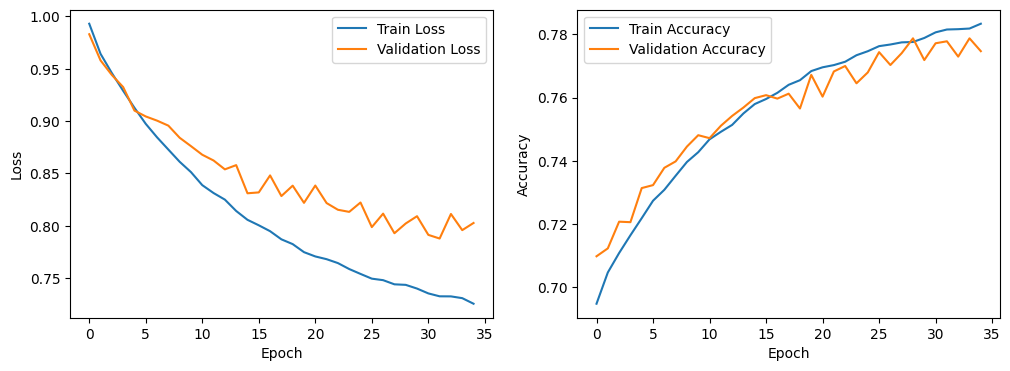

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()



## Text Generation function

In [ ]:
from tensorflow.keras.layers import Input

# Rebuild model for batch_size=1 inference
inputs = Input(batch_shape=(1, None), dtype='int32')
x = tf.keras.layers.Embedding(vocab_size, embedding_dim)(inputs)
x = tf.keras.layers.LSTM(rnn_units,
                         return_sequences=True,
                         stateful=True,
                         recurrent_initializer='glorot_uniform')(x)
outputs = tf.keras.layers.Dense(vocab_size)(x)

model_inf = tf.keras.Model(inputs, outputs)

# Load weights
model_inf.load_weights(checkpoint_path)

# Reset states function for stateful model
def reset_states(model):
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

def generate_text(model, start_string, num_generate=50, temperature=1.0):
    input_eval = [char2idx[c] for c in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []
    reset_states(model)

    for _ in range(num_generate):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0) / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)

# Example usage
print(generate_text(model_inf, start_string="To be or not to", num_generate=100))



To be or not to making him;
And for his skills, was wholefore 'twixt thee, breath,
Shall we desire to look on her.



## Evaluating the model performance

In [ ]:
# Prepare validation data (last 10k chars)
val_text = text_as_int[-10000:]
val_seq = tf.data.Dataset.from_tensor_slices(val_text).batch(seq_length + 1, drop_remainder=True)
val_seq = val_seq.map(split_input_target).batch(BATCH_SIZE, drop_remainder=True)

# Evaluate
val_loss, val_accuracy = model.evaluate(val_seq)
perplexity = np.exp(val_loss)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Perplexity: {perplexity:.2f}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7722 - loss: 0.7999
Validation Loss: 0.7999
Validation Accuracy: 0.7722
Validation Perplexity: 2.23


## Ablation Study

In [ ]:

# Ablation
rnn_units_ablate = 512
model_ablate = build_model(vocab_size, embedding_dim, rnn_units_ablate, batch_size=BATCH_SIZE)
model_ablate.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

# Train for fewer epochs
EPOCHS_ABLATE = 20
history_ablate = model_ablate.fit(dataset, epochs=EPOCHS_ABLATE)

# Evaluate ablated model
loss_ablate, acc_ablate = model_ablate.evaluate(val_seq)
perplexity_ablate = np.exp(loss_ablate)
print(f"Ablated Model Loss: {loss_ablate:.4f}")
print(f"Ablated Model Accuracy: {acc_ablate:.4f}")
print(f"Ablated Model Perplexity: {perplexity_ablate:.2f}")



Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2267 - loss: 2.9552
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.4094 - loss: 2.0258
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.4699 - loss: 1.7975
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5028 - loss: 1.6731
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5240 - loss: 1.5920
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5398 - loss: 1.5372
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5491 - loss: 1.5009
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5567 - loss: 1.4711
Epoch 9/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5647 - loss: 1.4401
Epoch 10/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.5691 - loss: 1.4229
Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5741 - loss: 1.4033
Epoch 12/20
172/172 ━━━━━━━━━━━━━━━━━